### Charts for Research Question 7.4:
#### If we simulate the disappearance of routine or highly automatable jobs, does the entire network stay connected, or does it break into disconnected fragments?

### Data Sources
The analysis is based on data generated by the following notebooks:

- `Routine_Workforce_Analysis_Notebook`
- `Random_Job_Removal_Analysis_Notebook`
- `Workforce_Analysis_Notebook`

### Required Files
- `occ_nodes_random_20.csv`
- `occ_edges_random_20.csv`
- `occ_nodes_random_30.csv`
- `occ_edges_random_30.csv`
- `occ_nodes_random_40.csv`
- `occ_edges_random_40.csv`
- `remaining_nodes_20.csv`
- `remaining_edges_20.csv`
- `remaining_nodes_30.csv`
- `remaining_edges_30.csv`
- `remaining_nodes_40.csv`
- `remaining_edges_40.csv`

### Tools
Google Gemini: Utilized for error correction and code restructuring.

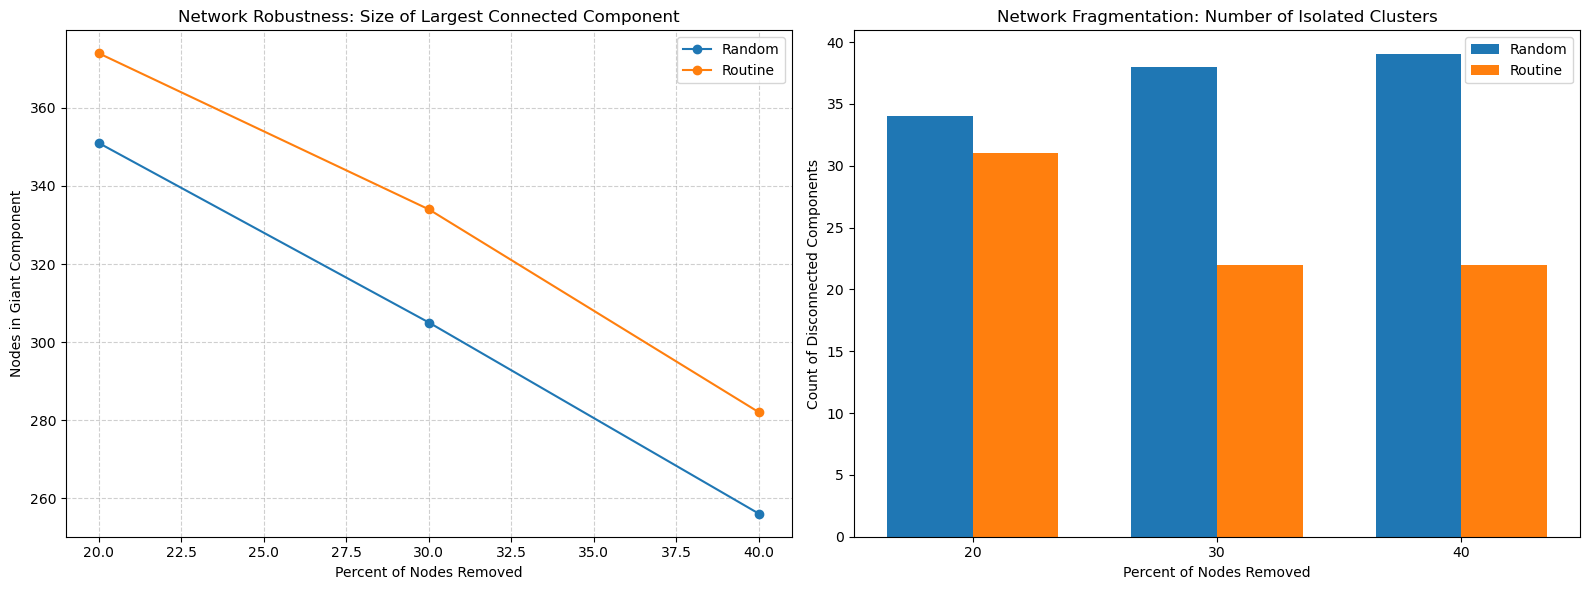

In [19]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def analyze_network_resilience(file_configs):
    """
    Reads CSV files for different removal scenarios and plots connectivity metrics
    
    Parameters:
    file_configs (list of dict): List containing scenario metadata and file paths.
    """
    results = []

    for config in file_configs:
        nodes_df = pd.read_csv(config['nodes'])
        edges_df = pd.read_csv(config['edges'])
        
        G = nx.Graph()
        
        G.add_nodes_from(nodes_df['Id'])
        G.add_edges_from(zip(edges_df['Source'], edges_df['Target']))
        
        # Calculate Connectivity Metrics
        num_nodes = G.number_of_nodes()
        if num_nodes > 0:
            # NetworkX Connected Components: 
            # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html
            components = sorted(nx.connected_components(G), key=len, reverse=True)
            lcc_size = len(components[0])
            num_components = len(components)
        else:
            lcc_size = 0
            num_components = 0
            
        results.append({
            'Percent Removed': config['percent'],
            'Strategy': config['type'],
            'LCC Size': lcc_size,
            'Fragments': num_components
        })

    df_results = pd.DataFrame(results)
    
    # Matplotlib Pyplot Subplots:
    # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Giant Component Line Plot
    strategies = df_results['Strategy'].unique()
    for strategy in strategies:
        # Filter and sort data for the specific removal strategy
        subset = df_results[df_results['Strategy'] == strategy].sort_values('Percent Removed')
        
        ax1.plot(subset['Percent Removed'], subset['LCC Size'], marker='o', label=strategy)

    ax1.set_title("Network Robustness: Size of Largest Connected Component")
    ax1.set_xlabel("Percent of Nodes Removed")
    ax1.set_ylabel("Nodes in Giant Component")
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Fragments Grouped Bar Chart
    percents = sorted(df_results['Percent Removed'].unique())
    x_indices = np.arange(len(percents))
    bar_width = 0.35

    for i, strategy in enumerate(strategies):
        # Align bar data with the sorted percent categories
        subset = df_results[df_results['Strategy'] == strategy].set_index('Percent Removed').reindex(percents).fillna(0)
        # Matplotlib Bar Chart:
        # https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html
        ax2.bar(x_indices + (i * bar_width), subset['Fragments'], width=bar_width, label=strategy)

    ax2.set_title("Network Fragmentation: Number of Isolated Clusters")
    ax2.set_xlabel("Percent of Nodes Removed")
    ax2.set_ylabel("Count of Disconnected Components")
    ax2.set_xticks(x_indices + (bar_width * (len(strategies) - 1) / 2))
    ax2.set_xticklabels(percents)
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig("network_analysis_results.png")
    plt.show()
    
    return df_results

my_files = [
    {'percent': 20, 'type': 'Random',  'nodes': 'occ_nodes_random_20.csv', 'edges': 'occ_edges_random_20.csv'},
    {'percent': 30, 'type': 'Random',  'nodes': 'occ_nodes_random_30.csv', 'edges': 'occ_edges_random_30.csv'},
    {'percent': 40, 'type': 'Random',  'nodes': 'occ_nodes_random_40.csv', 'edges': 'occ_edges_random_40.csv'},
    
    {'percent': 20, 'type': 'Routine', 'nodes': 'remaining_nodes_20.csv', 'edges': 'remaining_edges_20.csv'},
    {'percent': 30, 'type': 'Routine', 'nodes': 'remaining_nodes_30.csv', 'edges': 'remaining_edges_30.csv'},
    {'percent': 40, 'type': 'Routine', 'nodes': 'remaining_nodes_40.csv', 'edges': 'remaining_edges_40.csv'},
]

stats_df = analyze_network_resilience(my_files)

In [20]:
def generate_network_stats_table(file_configs):
    """
    Computes structural metrics and returns a DataFrame 
    where scenarios are columns and metrics are rows.
    """
    table_data = []

    for config in file_configs:
        # Load data
        nodes_df = pd.read_csv(config['nodes'])
        edges_df = pd.read_csv(config['edges'])
        
        # Build Graph
        G = nx.Graph()
        G.add_nodes_from(nodes_df['Id'])
        G.add_edges_from(zip(edges_df['Source'], edges_df['Target']))
        
        num_nodes = G.number_of_nodes()
        num_edges = G.number_of_edges()
        
        if num_nodes == 0:
            continue

        # Component Analysis
        components = sorted(nx.connected_components(G), key=len, reverse=True)
       
        lcc_subgraph = G.subgraph(components[0])
        
        # Metrics Calculation
        conn_components = len(components)
        lcc_size = len(components[0])
        lcc_percent = round((lcc_size / num_nodes) * 100, 2)
        
        avg_degree = round(sum(dict(G.degree()).values()) / num_nodes, 4) if num_nodes > 0 else 0
        
        # Average Clustering Coefficient:
        # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.average_clustering.html
        avg_clustering = round(nx.average_clustering(G), 4)
        
        if len(lcc_subgraph) > 1:
            # Average Shortest Path Length Algorithm:
            # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.average_shortest_path_length.html
            avg_path = round(nx.average_shortest_path_length(lcc_subgraph), 4)
        else:
            avg_path = 0

        # Create a descriptive column name for this scenario
        col_name = f"{config['type']} ({config['percent']}%)"

        # pandas Series:
        # https://pandas.pydata.org/docs/reference/api/pandas.Series.html
        table_data.append(pd.Series({
            "Total Nodes": num_nodes,
            "Total Edges": num_edges,
            "LCC Size": f"{lcc_size} ({lcc_percent}%)",
            "Avg Degree": avg_degree,
            "Avg Clustering": avg_clustering,
            "Avg Path (LCC)": avg_path,
            "Connected Components": conn_components
        }, name=col_name))

    # pandas concat:
    # https://pandas.pydata.org/docs/reference/api/pandas.concat.html
    stats_df = pd.concat(table_data, axis=1)
    
    return stats_df

table = generate_network_stats_table(my_files)
display(table)

,Random (20%),Random (30%),Random (40%),Routine (20%),Routine (30%),Routine (40%)
Total Nodes,420,368,315,421,367,316
Total Edges,2011,1535,1140,2570,2373,2135
LCC Size,351 (83.57%),305 (82.88%),256 (81.27%),374 (88.84%),334 (91.01%),282 (89.24%)
Avg Degree,9.5762,8.3424,7.2381,12.209,12.9319,13.5127
Avg Clustering,0.3499,0.3423,0.3272,0.3856,0.4159,0.4447
Avg Path (LCC),3.9345,3.9344,4.0402,3.8116,3.6352,3.3581
Connected Components,34,38,39,31,22,22


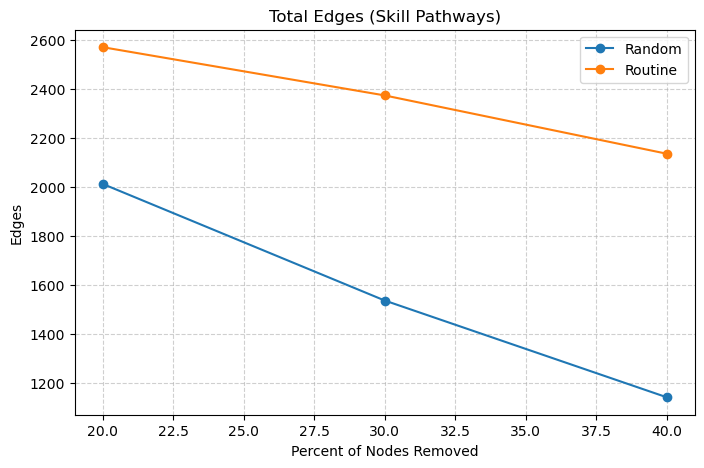

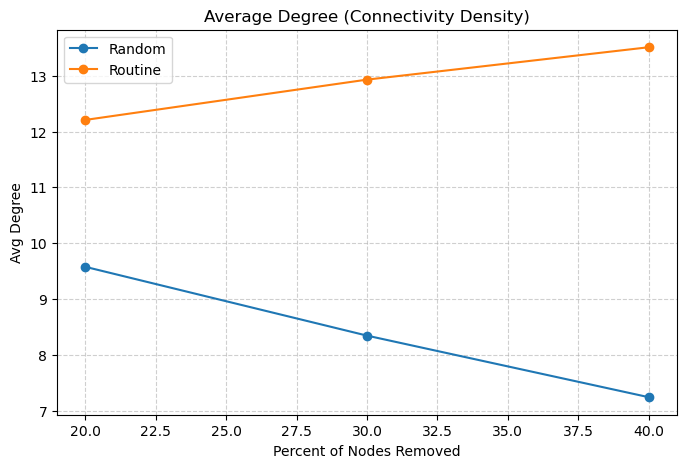

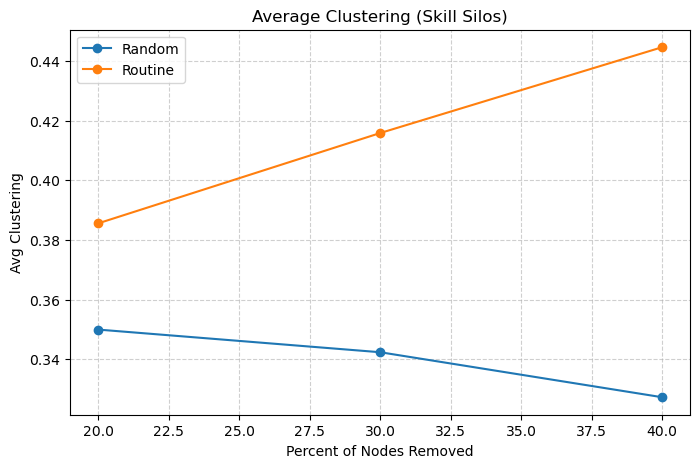

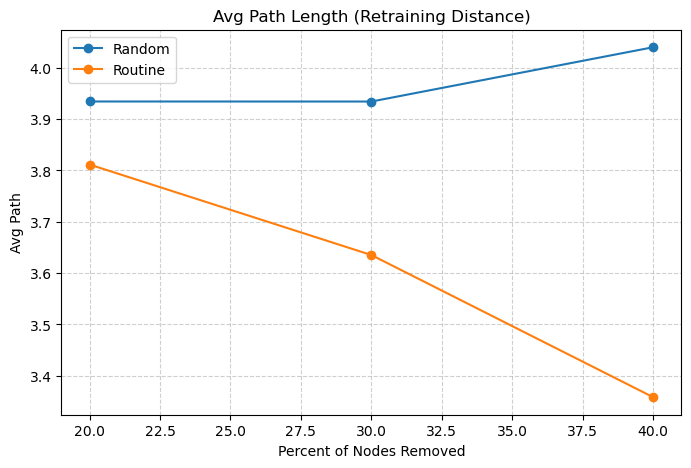

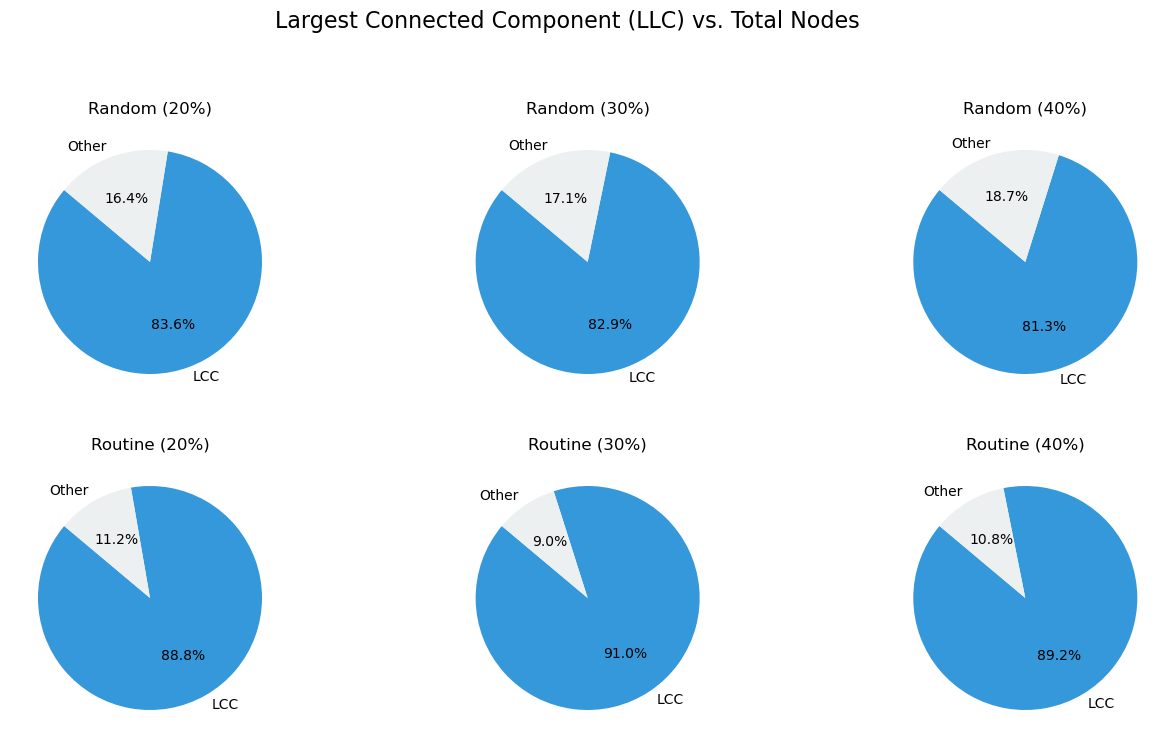

In [21]:
def generate_visual_analysis(file_configs):
    results = []

    for config in file_configs:
        try:
            nodes_df = pd.read_csv(config['nodes'])
            edges_df = pd.read_csv(config['edges'])
            
            G = nx.Graph()
            G.add_nodes_from(nodes_df['Id'])
            G.add_edges_from(zip(edges_df['Source'], edges_df['Target']))
            
            num_nodes = G.number_of_nodes()
            num_edges = G.number_of_edges()
            
            if num_nodes == 0: continue

            components = sorted(nx.connected_components(G), key=len, reverse=True)
            lcc_size = len(components[0])
            avg_degree = round(sum(dict(G.degree()).values()) / num_nodes, 4)
            avg_clustering = round(nx.average_clustering(G), 4)
            
            lcc_subgraph = G.subgraph(components[0])
            avg_path = nx.average_shortest_path_length(lcc_subgraph) if len(lcc_subgraph) > 1 else 0

            results.append({
                'Percent': config['percent'],
                'Strategy': config['type'],
                'Nodes': num_nodes,
                'Edges': num_edges,
                'LCC Size': lcc_size,
                'Avg Degree': avg_degree,
                'Avg Clustering': avg_clustering,
                'Avg Path': avg_path
            })
        
        except FileNotFoundError:
            print(f"Skipping missing file: {config['nodes']} or {config['edges']}")

    df = pd.DataFrame(results)
    
    # Line Charts for Metrics
    metrics_to_plot = [
        ('Edges', 'Total Edges (Skill Pathways)'),
        ('Avg Degree', 'Average Degree (Connectivity Density)'),
        ('Avg Clustering', 'Average Clustering (Skill Silos)'),
        ('Avg Path', 'Avg Path Length (Retraining Distance)')
    ]

    for col, title in metrics_to_plot:
        # Matplotlib Figure setup:
        # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html
        plt.figure(figsize=(8, 5))
        for strategy in df['Strategy'].unique():
            subset = df[df['Strategy'] == strategy].sort_values('Percent')
            plt.plot(subset['Percent'], subset[col], marker='o', label=strategy)
        
        plt.title(title)
        plt.xlabel("Percent of Nodes Removed")
        plt.ylabel(col)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

    # LCC Pie Charts
    num_scenarios = len(df)
    cols = 3
    rows = (num_scenarios // cols) + (1 if num_scenarios % cols != 0 else 0)
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    
    axes = axes.flatten()

    for i, (_, row) in enumerate(df.iterrows()):
        lcc = row['LCC Size']
        others = row['Nodes'] - lcc
        
        # Matplotlib Pie Chart:
        # https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.pie.html
        axes[i].pie([lcc, others], labels=['LCC', 'Other'], autopct='%1.1f%%', 
                    colors=['#3498db', '#ecf0f1'], startangle=140)
        axes[i].set_title(f"{row['Strategy']} ({row['Percent']}%)")

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle("Largest Connected Component (LLC) vs. Total Nodes", y=1.02, fontsize=16)
    plt.show()

generate_visual_analysis(my_files)

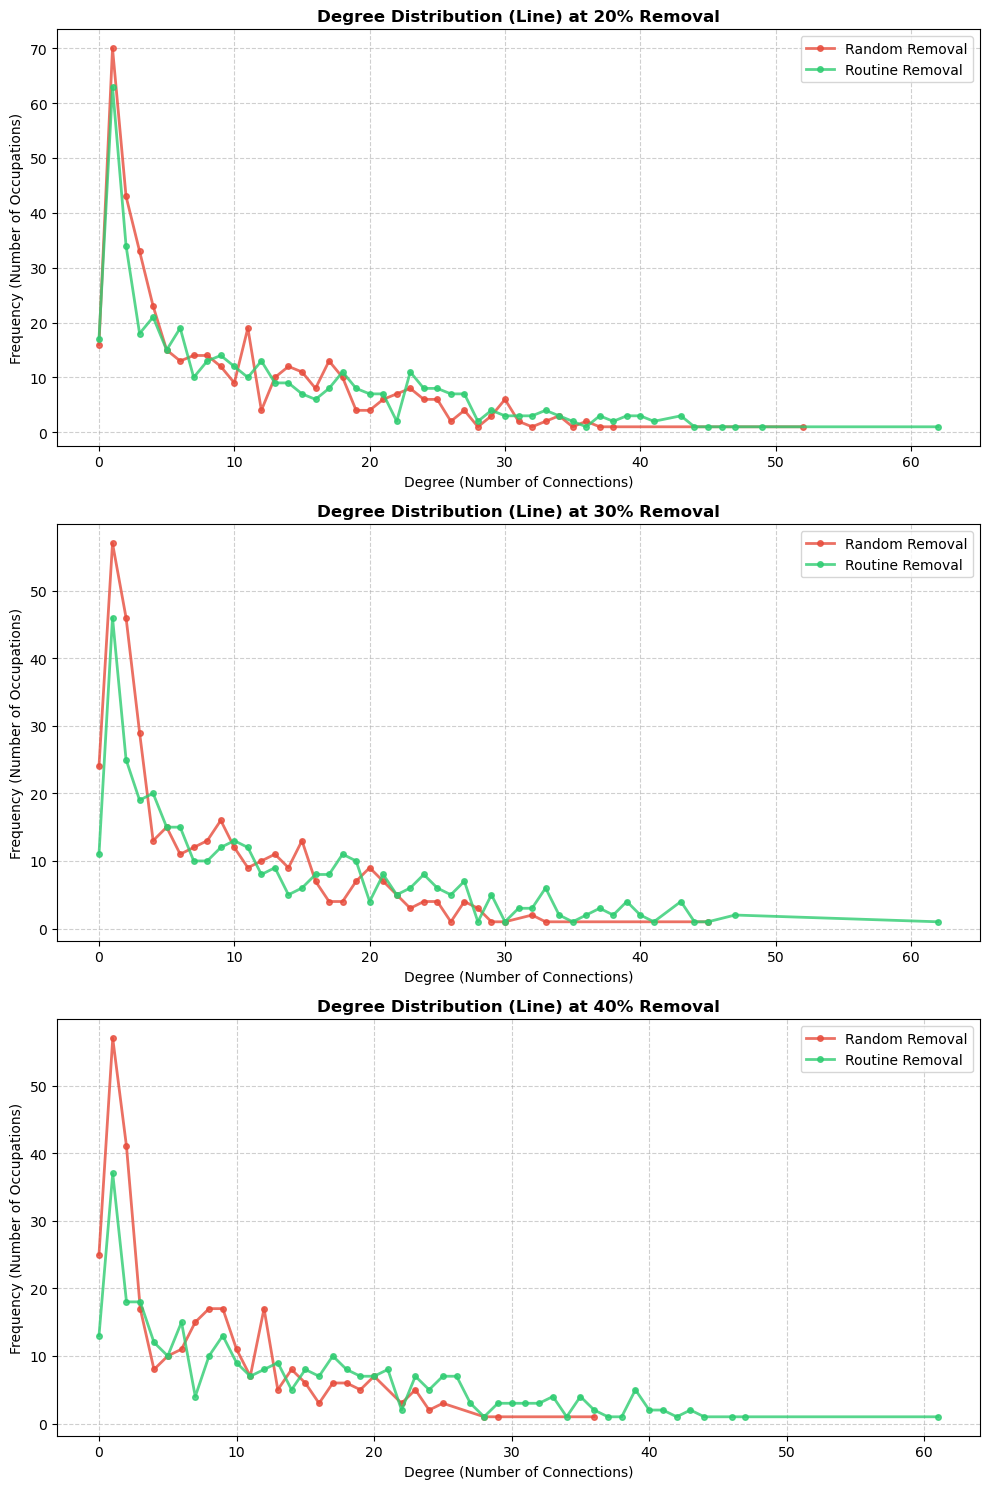

In [22]:
from collections import Counter

def plot_degree_distributions(file_configs):
    """
    Plots the degree distribution for each scenario to compare 
    how random vs. routine removal affects job connectivity.
    """
    # Group configurations by percentage to compare them side-by-side
    percents = sorted({c['percent'] for c in file_configs if c['percent'] > 0})
    
    fig, axes = plt.subplots(len(percents), 1, figsize=(10, 5 * len(percents)))
    if len(percents) == 1: 
        axes = [axes] 

    for idx, pct in enumerate(percents):
        ax = axes[idx]
        
        # Filter configs for this specific percentage
        for strategy, color in [('Random', '#e74c3c'), ('Routine', '#2ecc71')]:
            config = next((c for c in file_configs if c['percent'] == pct and c['type'] == strategy), None)
            
            if config:
                # Load and build graph
                nodes_df = pd.read_csv(config['nodes'])
                edges_df = pd.read_csv(config['edges'])
                G = nx.Graph()
                G.add_nodes_from(nodes_df['Id'])
                G.add_edges_from(zip(edges_df['Source'], edges_df['Target']))
                
                # Calculate frequency of each degree
                degrees = [d for n, d in G.degree()]
                
                degree_counts = Counter(degrees)
                
                # Sort degrees
                sorted_degrees = sorted(degree_counts.keys())
                frequencies = [degree_counts[d] for d in sorted_degrees]
                
                # Plot as Line Graph
                ax.plot(sorted_degrees, frequencies, marker='o', markersize=4, 
                        label=f"{strategy} Removal", color=color, linewidth=2, alpha=0.8)

        ax.set_title(f"Degree Distribution (Line) at {pct}% Removal", fontweight="bold")
        ax.set_xlabel("Degree (Number of Connections)")
        ax.set_ylabel("Frequency (Number of Occupations)")
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_degree_distributions(my_files)